Project Title: Global Food Security Predictor

A Neural Network Linear Regression Model to predict the hunger severity using real-world food security data.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter('ignore')

In [ ]:
np.set_printoptions(precision=3, suppress=True)

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers  # It builds and trains computational graphs for learning patterns.

In [ ]:
import kagglehub

def using_kagglehub():
    path = kagglehub.dataset_download("kanchana1990/global-food-security-intelligence")
    return pd.read_csv(f"{path}/global_food_security_intelligence.csv")

df = using_kagglehub()
print(df.head())

100%|██████████| 549k/549k [00:00<00:00, 1.28MB/s]

Extracting files...


  country_code iso3 country_name  year                      region  \
0          ABW  ABW        Aruba  2000  Latin America & Caribbean    
1          ABW  ABW        Aruba  2001  Latin America & Caribbean    
2          ABW  ABW        Aruba  2002  Latin America & Caribbean    
3          ABW  ABW        Aruba  2003  Latin America & Caribbean    
4          ABW  ABW        Aruba  2004  Latin America & Caribbean    

  income_group    lending_type capital_city  latitude  longitude  ...  \
0  High income  Not classified   Oranjestad   12.5167   -70.0167  ...   
1  High income  Not classified   Oranjestad   12.5167   -70.0167  ...   
2  High income  Not classified   Oranjestad   12.5167   -70.0167  ...   
3  High income  Not classified   Oranjestad   12.5167   -70.0167  ...   
4  High income  Not classified   Oranjestad   12.5167   -70.0167  ...   

   food_crop_production_gap  protein_adequacy_score  \
0                       NaN                     NaN   
1                       NaN   

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5208 entries, 0 to 5207
Data columns (total 57 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   country_code                           5208 non-null   object 
 1   iso3                                   5208 non-null   object 
 2   country_name                           5208 non-null   object 
 3   year                                   5208 non-null   int64  
 4   region                                 5208 non-null   object 
 5   income_group                           5208 non-null   object 
 6   lending_type                           5208 non-null   object 
 7   capital_city                           5064 non-null   object 
 8   latitude                               5064 non-null   float64
 9   longitude                              5064 non-null   float64
 10  agricultural_land_pct                  5002 non-null   float64
 11  arab

In [ ]:
df.tail()

,country_code,iso3,country_name,year,region,income_group,lending_type,capital_city,latitude,longitude,...,food_crop_production_gap,protein_adequacy_score,agriculture_dependence_index,undernourishment_yoy_change_pp,row_completeness_pct,country_iso3,data_version,compiled_date,source_wb,source_fao
5203,ZWE,ZWE,Zimbabwe,2019,Sub-Saharan Africa,Lower middle income,Blend,Harare,-17.8312,31.0672,...,1.45,100.0,52.11,-1.0,100.0,ZW,v1.0,2026-04-08,World Bank WDI API,FAOSTAT Bulk Download
5204,ZWE,ZWE,Zimbabwe,2020,Sub-Saharan Africa,Lower middle income,Blend,Harare,-17.8312,31.0672,...,-17.43,100.0,50.21,-1.8,91.7,ZW,v1.0,2026-04-08,World Bank WDI API,FAOSTAT Bulk Download
5205,ZWE,ZWE,Zimbabwe,2021,Sub-Saharan Africa,Lower middle income,Blend,Harare,-17.8312,31.0672,...,-9.45,100.0,47.72,-3.4,91.7,ZW,v1.0,2026-04-08,World Bank WDI API,FAOSTAT Bulk Download
5206,ZWE,ZWE,Zimbabwe,2022,Sub-Saharan Africa,Lower middle income,Blend,Harare,-17.8312,31.0672,...,-1.80,NaN,47.56,-3.4,83.3,ZW,v1.0,2026-04-08,World Bank WDI API,FAOSTAT Bulk Download
5207,ZWE,ZWE,Zimbabwe,2023,Sub-Saharan Africa,Lower middle income,Blend,Harare,-17.8312,31.0672,...,NaN,NaN,48.62,-1.7,58.3,ZW,v1.0,2026-04-08,World Bank WDI API,FAOSTAT Bulk Download


In [ ]:
print(df.shape)

(5208, 57)


In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
drop_cols = [
    'country_code', 'iso3', 'country_name',
    'region', 'income_group', 'lending_type',
    'capital_city', 'latitude', 'longitude',
    'country_iso3', 'data_version', 'compiled_date',
    'source_wb', 'source_fao'
]

df = df.drop(columns=drop_cols, errors='ignore')

In [ ]:
df['hunger_severity_index'] = (
    df['undernourishment_pct'] * 0.4 +
    df['poverty_headcount_pct'] * 0.2 +
    df['child_mortality_per_1000'] * 0.2 +
    df['fao_child_stunting_pct'] * 0.2
)

In [ ]:
from sklearn.impute import SimpleImputer

numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print(f"Imputing {len(numerical_cols)} numerical columns with median...")
print(f"Imputing {len(categorical_cols)} categorical columns with mode...")

for col in numerical_cols:
    imputer = SimpleImputer(strategy='median')
    df[col] = imputer.fit_transform(df[[col]]).flatten()


for col in categorical_cols:
    imputer = SimpleImputer(strategy='most_frequent')
    df[col] = imputer.fit_transform(df[[col]]).flatten()

print("\nNaNs in df after comprehensive imputation:")
display(df.isnull().sum().sum())

Imputing 43 numerical columns with median...
Imputing 0 categorical columns with mode...

NaNs in df after comprehensive imputation:


np.int64(0)

In [ ]:
target = 'hunger_severity_index'

X = df.drop(columns=[target])
y = df[target]

In [ ]:
X = X.fillna(X.median())

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(4166, 42)
(1042, 42)


In [ ]:
print(df.shape)

(5208, 43)


In [ ]:
print(df.shape)
print(df.isnull().sum().sort_values(ascending=False).head(10))

(5208, 43)
year                             0
agricultural_land_pct            0
arable_land_pct                  0
cereal_yield_kg_per_ha           0
child_mortality_per_1000         0
crop_production_index            0
employment_in_agriculture_pct    0
food_imports_pct_merchandise     0
food_production_index            0
freshwater_withdrawal_pct        0
dtype: int64


In [ ]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
df.head()

,year,agricultural_land_pct,arable_land_pct,cereal_yield_kg_per_ha,child_mortality_per_1000,crop_production_index,employment_in_agriculture_pct,food_imports_pct_merchandise,food_production_index,freshwater_withdrawal_pct,...,fao_undernourishment_pct,hunger_severity_index,economic_vulnerability_index,food_crisis_flag,undernourished_pop_millions,food_crop_production_gap,protein_adequacy_score,agriculture_dependence_index,undernourishment_yoy_change_pp,row_completeness_pct
0,2000.0,11.111111,11.111111,2682.8,20.2,95.99,18.7389,70.686869,96.53,11.175115,...,10.3,7.72,32.12,0.0,1.0275,0.06,100.0,5.56,0.0,33.3
1,2001.0,11.111111,11.111111,2682.8,20.2,95.99,18.7389,69.394325,96.53,11.175115,...,10.3,7.72,31.92,0.0,1.0275,0.06,100.0,5.56,0.0,33.3
2,2002.0,11.111111,11.111111,2682.8,20.2,95.99,18.7389,68.666458,96.53,11.175115,...,10.3,7.72,31.92,0.0,1.0275,0.06,100.0,5.56,0.0,33.3
3,2003.0,11.111111,11.111111,2682.8,20.2,95.99,18.7389,70.063078,96.53,11.175115,...,10.3,7.72,31.89,0.0,1.0275,0.06,100.0,5.56,0.0,33.3
4,2004.0,11.111111,11.111111,2682.8,20.2,95.99,18.7389,67.765371,96.53,11.175115,...,10.3,7.72,31.48,0.0,1.0275,0.06,100.0,5.56,0.0,33.3


In [ ]:
train_df = df.sample(frac=0.8, random_state=0)
test_df = df.drop(train_df.index)

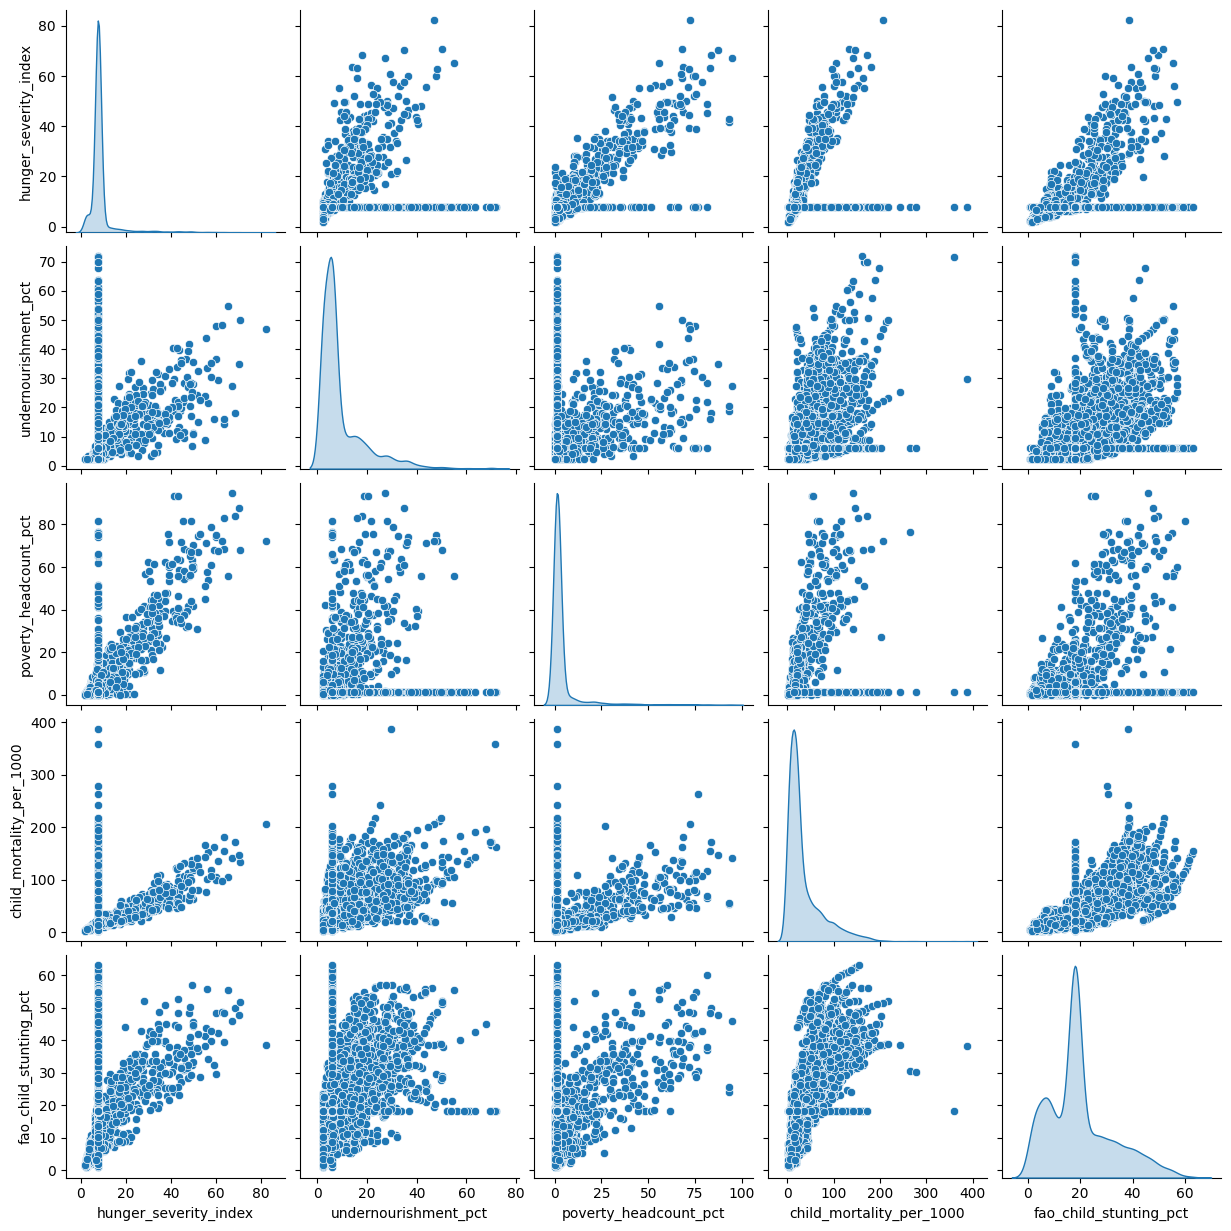

In [ ]:
sns.pairplot(train_df[['hunger_severity_index', 'undernourishment_pct', 'poverty_headcount_pct', 'child_mortality_per_1000', 'fao_child_stunting_pct']], diag_kind='kde')


In [ ]:
train_df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
year,4166.0,2.011520e+03,6.896663e+00,2000.000000,2006.000000,2.012000e+03,2.018000e+03,2.023000e+03
agricultural_land_pct,4166.0,3.729569e+01,2.203606e+01,0.436116,18.750293,3.850416e+01,5.318621e+01,8.548737e+01
arable_land_pct,4166.0,1.353709e+01,1.337651e+01,0.043141,3.149389,9.886758e+00,1.905988e+01,6.414688e+01
cereal_yield_kg_per_ha,4166.0,3.202843e+03,2.668317e+03,0.100000,1695.225000,2.682800e+03,3.836275e+03,3.676190e+04
child_mortality_per_1000,4166.0,3.515118e+01,3.895636e+01,1.500000,9.600000,2.020000e+01,4.550000e+01,3.874000e+02
crop_production_index,4166.0,9.486470e+01,2.408075e+01,17.000000,85.675000,9.599000e+01,1.027975e+02,6.254300e+02
employment_in_agriculture_pct,4166.0,2.479394e+01,2.100354e+01,0.090952,6.803722,1.873890e+01,3.784300e+01,9.193755e+01
food_imports_pct_merchandise,4166.0,4.685371e+01,2.673012e+01,1.127673,31.008377,4.110297e+01,5.559249e+01,3.389297e+02
food_production_index,4166.0,9.445384e+01,2.069274e+01,17.000000,86.640000,9.653000e+01,1.021600e+02,5.021400e+02
freshwater_withdrawal_pct,4166.0,5.223255e+01,2.453329e+02,0.027208,5.640353,1.117512e+01,2.484282e+01,3.850500e+03


In [ ]:
train_df.columns

Index(['year', 'agricultural_land_pct', 'arable_land_pct',
       'cereal_yield_kg_per_ha', 'child_mortality_per_1000',
       'crop_production_index', 'employment_in_agriculture_pct',
       'food_imports_pct_merchandise', 'food_production_index',
       'freshwater_withdrawal_pct', 'gdp_per_capita_usd',
       'inflation_consumer_prices_pct', 'population_total',
       'poverty_headcount_pct', 'stunting_prevalence_pct',
       'undernourishment_pct', 'fao_animal_protein_g_per_day',
       'fao_basic_sanitation_pct', 'fao_basic_water_access_pct',
       'fao_cereal_import_dependency_pct', 'fao_child_stunting_millions',
       'fao_child_stunting_pct', 'fao_child_wasting_millions',
       'fao_dietary_energy_adequacy_pct', 'fao_fat_supply_g_per_day',
       'fao_gdp_per_capita_ppp', 'fao_low_birthweight_millions',
       'fao_min_dietary_energy_req_kcal',
       'fao_mod_severe_food_insecure_millions', 'fao_protein_supply_g_per_day',
       'fao_safe_water_pct', 'fao_severe_food_insecu

In [ ]:
train_features = train_df.copy()
test_features = test_df.copy()

train_labels = train_features.pop('hunger_severity_index')
test_labels = test_features.pop('hunger_severity_index')

In [ ]:
df.head()

,year,agricultural_land_pct,arable_land_pct,cereal_yield_kg_per_ha,child_mortality_per_1000,crop_production_index,employment_in_agriculture_pct,food_imports_pct_merchandise,food_production_index,freshwater_withdrawal_pct,...,fao_undernourishment_pct,hunger_severity_index,economic_vulnerability_index,food_crisis_flag,undernourished_pop_millions,food_crop_production_gap,protein_adequacy_score,agriculture_dependence_index,undernourishment_yoy_change_pp,row_completeness_pct
0,2000.0,11.111111,11.111111,2682.8,20.2,95.99,18.7389,70.686869,96.53,11.175115,...,10.3,7.72,32.12,0.0,1.0275,0.06,100.0,5.56,0.0,33.3
1,2001.0,11.111111,11.111111,2682.8,20.2,95.99,18.7389,69.394325,96.53,11.175115,...,10.3,7.72,31.92,0.0,1.0275,0.06,100.0,5.56,0.0,33.3
2,2002.0,11.111111,11.111111,2682.8,20.2,95.99,18.7389,68.666458,96.53,11.175115,...,10.3,7.72,31.92,0.0,1.0275,0.06,100.0,5.56,0.0,33.3
3,2003.0,11.111111,11.111111,2682.8,20.2,95.99,18.7389,70.063078,96.53,11.175115,...,10.3,7.72,31.89,0.0,1.0275,0.06,100.0,5.56,0.0,33.3
4,2004.0,11.111111,11.111111,2682.8,20.2,95.99,18.7389,67.765371,96.53,11.175115,...,10.3,7.72,31.48,0.0,1.0275,0.06,100.0,5.56,0.0,33.3


In [ ]:
normalizer = tf.keras.layers.Normalization(axis=-1)
normalizer.adapt(np.array(train_features))

In [ ]:
print(normalizer.mean.numpy())

[[    2011.52        37.296       13.537     3202.843       35.151
        94.865       24.794       46.854       94.454       52.233
     15969.415        6.211 33812552.           4.108       23.58
         9.581       37.746       75.444       87.141       32.134
         1.149       19.942        0.341      120.518       84.857
     21392.463        0.147     1822.222        4.016       82.25
        70.362        1.395        5.902       12.032       34.085
         0.083        4.465       -0.482       99.397       28.934
        -0.152       75.565]]


In [ ]:
first = np.array(train_features[:1])

with np.printoptions(precision=2, suppress=True):
  print('First example:', first)
  print()
  print('Normalized:', normalizer(first).numpy())

First example: [[   2006.        62.58       5.54     798.5       64.6      114.78
       56.4       38.36      99.62      11.18     448.         3.53
  2703502.         1.4       23.6        6.2       36.1       10.
       49.        37.5        0.2       48.         0.3      121.
       82.3    13690.         0.1     1691.         2.9       81.7
       75.         1.1        5.        10.3       34.09       0.
        1.03     -15.16     100.        59.49       0.        58.3 ]]

Normalized: [[-0.8   1.15 -0.6  -0.9   0.76  0.83  1.5  -0.32  0.25 -0.17 -0.62 -0.14
  -0.23 -0.26  0.   -0.35 -0.09 -2.45 -2.36  0.08 -0.23  2.28 -0.05  0.04
  -0.09 -0.33 -0.09 -1.48 -0.15 -0.03  0.2  -0.12 -0.17 -0.23  0.   -0.3
  -0.21 -1.31  0.17  1.68  0.17 -0.77]]


In [ ]:
test_df.head()

,year,agricultural_land_pct,arable_land_pct,cereal_yield_kg_per_ha,child_mortality_per_1000,crop_production_index,employment_in_agriculture_pct,food_imports_pct_merchandise,food_production_index,freshwater_withdrawal_pct,...,fao_undernourishment_pct,hunger_severity_index,economic_vulnerability_index,food_crisis_flag,undernourished_pop_millions,food_crop_production_gap,protein_adequacy_score,agriculture_dependence_index,undernourishment_yoy_change_pp,row_completeness_pct
0,2000.0,11.111111,11.111111,2682.8,20.2,95.99,18.738900,70.686869,96.53,11.175115,...,10.3,7.72,32.12,0.0,1.0275,0.06,100.00,5.56,0.0,33.3
7,2007.0,11.111111,11.111111,2682.8,20.2,95.99,18.738900,74.911047,96.53,11.175115,...,10.3,7.72,31.55,0.0,1.0275,0.06,100.00,5.56,0.0,33.3
21,2021.0,11.111111,11.111111,2682.8,20.2,95.99,18.738900,72.397893,96.53,11.175115,...,10.3,7.72,30.67,0.0,1.0275,0.06,100.00,5.56,0.0,25.0
24,2000.0,57.945817,11.779587,806.3,131.7,50.23,63.450774,41.102967,67.78,54.757019,...,10.3,7.72,34.12,0.0,1.0275,17.55,100.00,60.70,0.0,58.3
25,2001.0,57.947350,11.779587,1006.7,127.4,52.08,64.523169,41.102967,61.59,54.757019,...,45.8,7.72,34.13,1.0,9.2900,9.51,99.81,61.24,0.0,83.3


In [ ]:
from sklearn.impute import SimpleImputer

feature_imputer = SimpleImputer(strategy='median')

train_features_imputed = pd.DataFrame(feature_imputer.fit_transform(train_features),
                                        columns=train_features.columns,
                                        index=train_features.index)
test_features_imputed = pd.DataFrame(feature_imputer.transform(test_features),
                                       columns=test_features.columns,
                                       index=test_features.index)


label_imputer = SimpleImputer(strategy='median')

train_labels_imputed = pd.Series(label_imputer.fit_transform(train_labels.values.reshape(-1, 1)).flatten(),
                                 index=train_labels.index,
                                 name=train_labels.name)
test_labels_imputed = pd.Series(label_imputer.transform(test_labels.values.reshape(-1, 1)).flatten(),
                                index=test_labels.index,
                                name=test_labels.name)


train_features = train_features_imputed
test_features = test_features_imputed
train_labels = train_labels_imputed
test_labels = test_labels_imputed

In [ ]:
linear_model = tf.keras.Sequential([
    normalizer,
    layers.Dense(units=1)
])

In [ ]:
linear_model.predict(train_features[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step


array([[-0.472],
       [ 0.955],
       [-2.115],
       [ 0.364],
       [-1.547],
       [ 1.147],
       [ 0.071],
       [ 0.45 ],
       [ 1.293],
       [ 0.513]], dtype=float32)

In [ ]:
linear_model.layers[1].kernel

<Variable path=sequential/dense/kernel, shape=(42, 1), dtype=float32, value=[[-0.219]
 [-0.161]
 [-0.12 ]
 [-0.334]
 [ 0.34 ]
 [ 0.073]
 [-0.137]
 [ 0.269]
 [ 0.214]
 [ 0.252]
 [ 0.07 ]
 [-0.161]
 [ 0.227]
 [-0.35 ]
 [-0.074]
 [-0.001]
 [-0.216]
 [ 0.322]
 [-0.002]
 [ 0.094]
 [-0.265]
 [-0.119]
 [-0.017]
 [ 0.15 ]
 [-0.347]
 [ 0.179]
 [ 0.372]
 [-0.144]
 [-0.11 ]
 [-0.291]
 [-0.228]
 [-0.137]
 [ 0.235]
 [ 0.358]
 [ 0.27 ]
 [ 0.002]
 [-0.291]
 [-0.187]
 [-0.193]
 [-0.162]
 [ 0.11 ]
 [-0.031]]>

In [ ]:
linear_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
    loss='mean_absolute_error')

In [ ]:
early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

linear_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
    loss='mean_absolute_error'
)

print("Model re-compiled and Early Stopping callback defined.")

Model re-compiled and Early Stopping callback defined.


In [ ]:
%%time
history_early_stop = linear_model.fit(
    train_features,
    train_labels,
    epochs=200,
    verbose=1,
    validation_split=0.2,
    callbacks=[early_stopping_callback]
)

print("Training finished with Early Stopping. Plotting new loss curves...")

Epoch 1/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 4.6492 - val_loss: 1.9439
Epoch 2/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.6981 - val_loss: 1.6390
Epoch 3/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.6698 - val_loss: 1.6957
Epoch 4/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.6761 - val_loss: 1.7067
Epoch 5/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.5983 - val_loss: 1.5753
Epoch 6/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.5949 - val_loss: 1.5492
Epoch 7/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.6053 - val_loss: 1.6189
Epoch 8/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.6118 - val_loss: 1.6131
Epoch 9/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.5890 - val_loss: 1.6174
Epoch 10/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.6344 - val_loss: 1.5856
Epoch 11/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.6686 - val_loss: 1.9787
Epoch 12/200
105/105 ━━━━━━━━━━━━━━━━━━━━

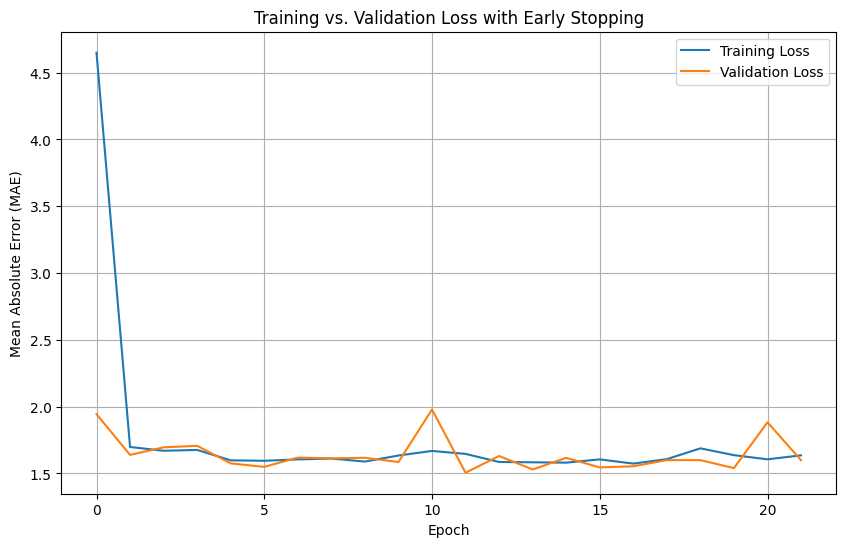

Train loss after early stopping: 1.5162595510482788
Test loss after early stopping: 1.6743371486663818


In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history_early_stop.history['loss'], label='Training Loss')
plt.plot(history_early_stop.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('Training vs. Validation Loss with Early Stopping')
plt.legend()
plt.grid(True)
plt.show()

new_train_loss = linear_model.evaluate(train_features, train_labels, verbose=0)
new_test_loss = linear_model.evaluate(test_features, test_labels, verbose=0)

print(f"Train loss after early stopping: {new_train_loss}")
print(f"Test loss after early stopping: {new_test_loss}")

In [ ]:
%%time
history = linear_model.fit(
    train_features,
    train_labels,
    epochs=100,
    verbose=0,
    validation_split = 0.2)

CPU times: user 31.5 s, sys: 1.35 s, total: 32.8 s
Wall time: 29.7 s


In [ ]:
test_results = {}
test_results['linear_model'] = linear_model.evaluate(
    test_features, test_labels, verbose=0)

In [ ]:
train_loss = linear_model.evaluate(train_features, train_labels, verbose=0)
test_loss = linear_model.evaluate(test_features, test_labels, verbose=0)

print("Train loss:", train_loss)
print("Test loss:", test_loss)

Train loss: 1.5795789957046509
Test loss: 1.7036182880401611


In [ ]:
test_predictions = linear_model.predict(test_features).flatten()

predictions_df = pd.DataFrame({
    'Actual': test_labels,
    'Predicted': test_predictions
})
print("Sample of Test Predictions vs Actuals:")
display(predictions_df.head(10))


33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Sample of Test Predictions vs Actuals:


,Actual,Predicted
0,7.72,7.144979
7,7.72,7.361547
21,7.72,7.872245
24,7.72,7.139846
25,7.72,7.640077
28,7.72,8.062562
35,7.72,7.773778
56,47.92,19.642225
60,7.72,7.398877
62,7.72,7.728410


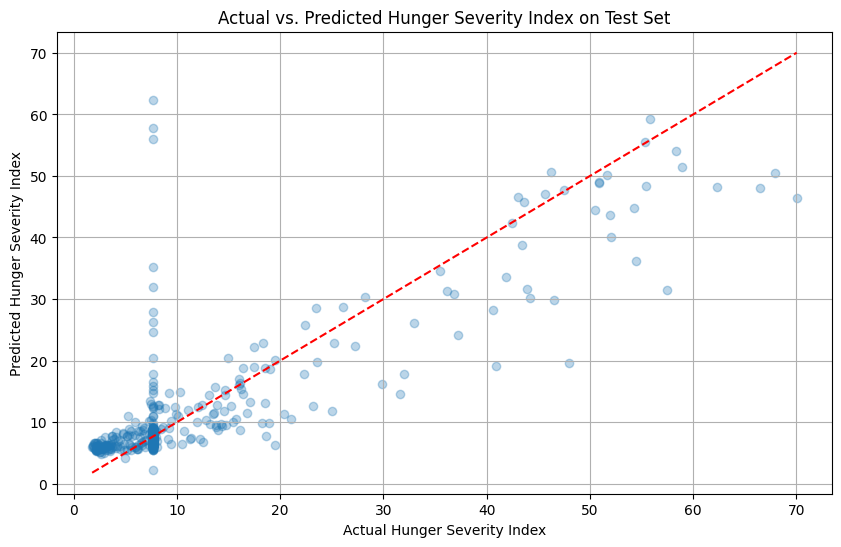

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(test_labels, test_predictions, alpha=0.3)
plt.xlabel('Actual Hunger Severity Index')
plt.ylabel('Predicted Hunger Severity Index')
plt.title('Actual vs. Predicted Hunger Severity Index on Test Set')
plt.plot([min(test_labels), max(test_labels)], [min(test_labels), max(test_labels)], color='red', linestyle='--') # y=x line
plt.grid(True)
plt.show()


In [ ]:
# Save the trained model
linear_model.save('food_security_model.keras')

# Save the normalizer stats so the app can scale inputs the same way
import json
normalizer_config = {
    'mean': normalizer.mean.numpy().tolist(),
    'variance': normalizer.variance.numpy().tolist()
}
with open('normalizer_config.json', 'w') as f:
    json.dump(normalizer_config, f)

print("Model and normalizer saved!")

Model and normalizer saved!


In [ ]:
from google.colab import files
files.download('food_security_model.keras')
files.download('normalizer_config.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>